In [4]:
import pandas as pd
df = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\AB_NYC_2019.csv (1).zip")
df.drop_duplicates(inplace=True)
df = df[df['price'] < 1000]
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 48597 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48597 non-null  int64  
 1   name                            48581 non-null  object 
 2   host_id                         48597 non-null  int64  
 3   host_name                       48576 non-null  object 
 4   neighbourhood_group             48597 non-null  object 
 5   neighbourhood                   48597 non-null  object 
 6   latitude                        48597 non-null  float64
 7   longitude                       48597 non-null  float64
 8   room_type                       48597 non-null  object 
 9   price                           48597 non-null  int64  
 10  minimum_nights                  48597 non-null  int64  
 11  number_of_reviews               48597 non-null  int64  
 12  last_review                     38706

In [10]:
expensive_neigh = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
print(expensive_neigh.head(10))
room_type_stats = df.groupby('room_type')['price'].mean()
print(room_type_stats)
availability_stats = df['availability_365'].value_counts()
print(availability_stats)
correlation = df[['number_of_reviews','price']].corr()
print(correlation)


neighbourhood
Fort Wadsworth       800.000000
Woodrow              700.000000
Tribeca              309.468750
NoHo                 276.246753
Flatiron District    275.052632
Neponsit             274.666667
Midtown              263.763469
SoHo                 250.057471
Willowbrook          249.000000
West Village         238.483400
Name: price, dtype: float64
room_type
Entire home/apt    192.932806
Private room        84.555196
Shared room         66.001730
Name: price, dtype: float64
availability_365
0      17449
365     1246
364      474
1        408
89       358
       ...  
195       26
183       24
196       24
181       23
202       20
Name: count, Length: 366, dtype: int64
                   number_of_reviews     price
number_of_reviews           1.000000 -0.056826
price                      -0.056826  1.000000


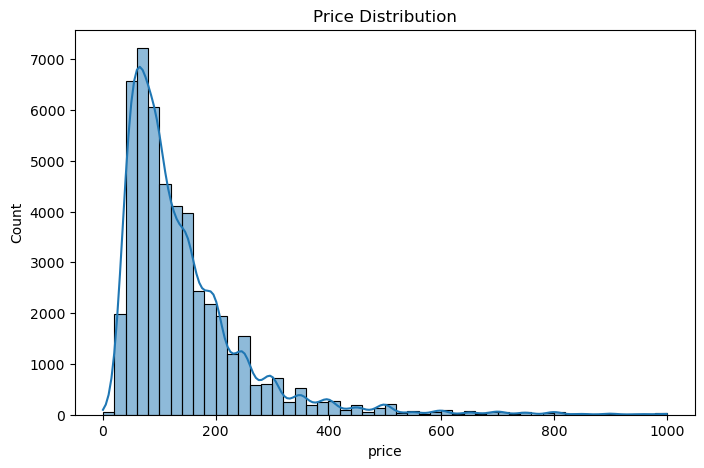

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()


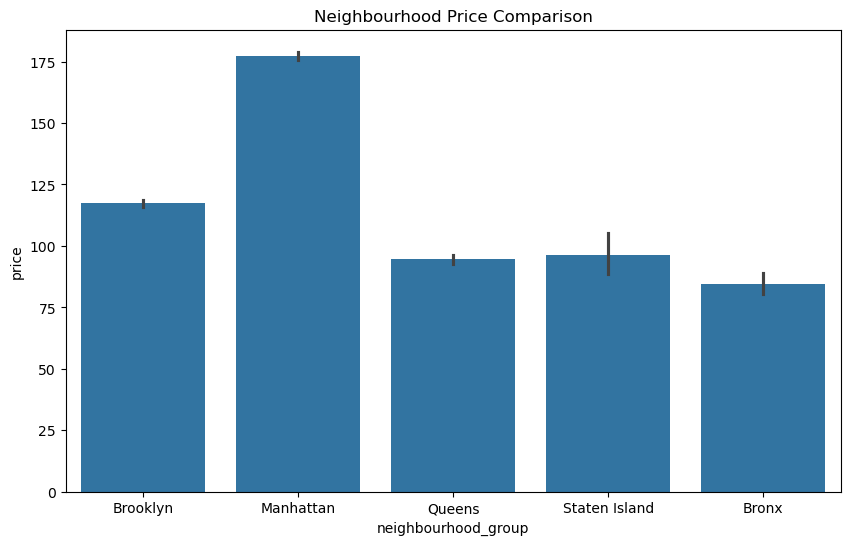

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x='neighbourhood_group', y='price', data=df)
plt.title("Neighbourhood Price Comparison")
plt.show()


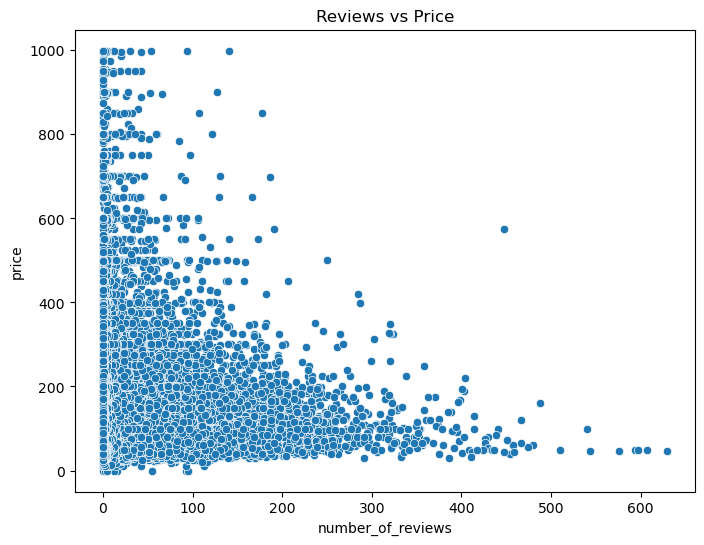

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='number_of_reviews', y='price', data=df)
plt.title("Reviews vs Price")
plt.show()
